# 06v2 — Comparaison Text vs Multimodal

 toute la logique est dans `src/evaluation/comparison_analysis.py`.

In [2]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

## 1. Vue globale — toutes les expériences AFC

/workspace/patootie_code/mm_argfallacy/mmarg_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 13427.86it/s]


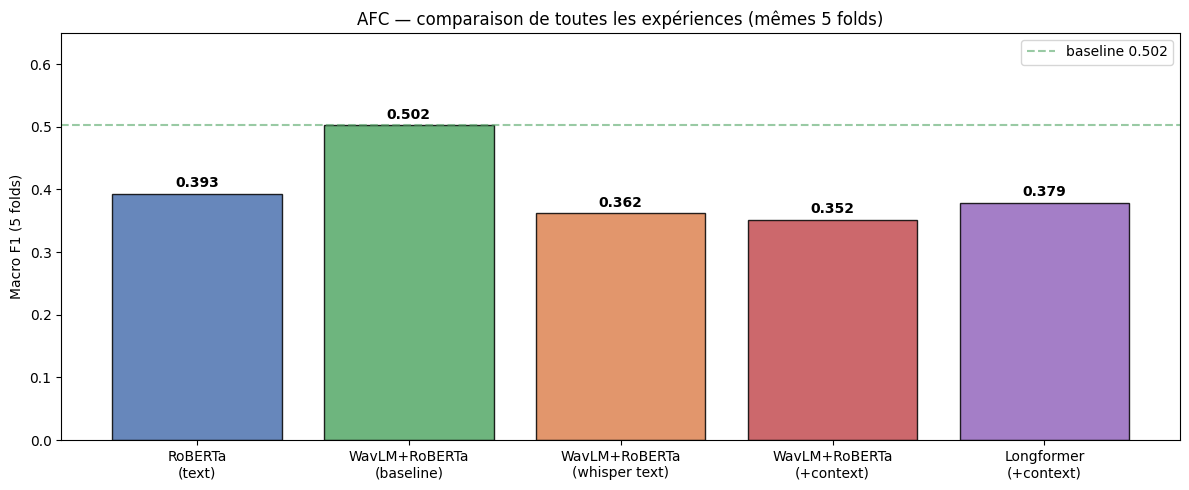


=== Résumé ===
  RoBERTa (text)                      0.3934  Δ=-0.1089 ✗
  WavLM+RoBERTa (baseline)            0.5022  Δ=+0.0000 ✓
  WavLM+RoBERTa (whisper text)        0.3623  Δ=-0.1399 ✗
  WavLM+RoBERTa (+context)            0.3521  Δ=-0.1502 ✗
  Longformer (+context)               0.3792  Δ=-0.1231 ✗


In [3]:
from analyses.comparison_analysis import plot_all_experiments

plot_all_experiments(
    save_path=ROOT / "results/figures/all_experiments_afc.png"
)

## 2. Text vs Multimodal baseline — macro F1 par fold

In [5]:
from analyses.comparison_analysis import load_results, build_comparison_df

text_results, mm_results = load_results()
comp_df = build_comparison_df(text_results, mm_results)
comp_df

,dialogue,text,multimodal,delta
0,13_1988,0.335389,0.465988,0.130599
1,22_1996,0.297178,0.563636,0.266458
2,25_2000,0.435185,0.430124,-0.005061
3,31_2004,0.485069,0.564815,0.079745
4,46_2020,0.449591,0.475076,0.025485


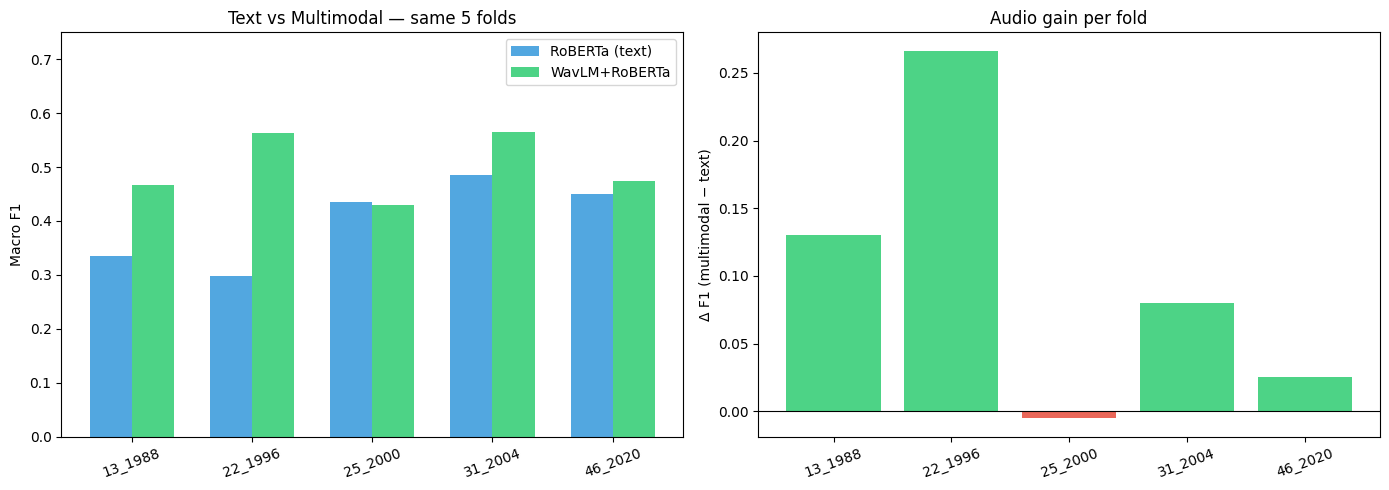

dialogue     text  multimodal     delta
 13_1988 0.335389    0.465988  0.130599
 22_1996 0.297178    0.563636  0.266458
 25_2000 0.435185    0.430124 -0.005061
 31_2004 0.485069    0.564815  0.079745
 46_2020 0.449591    0.475076  0.025485

Mean text      : 0.400
Mean multimodal: 0.500
Mean delta     : +0.099


In [6]:
from analyses.comparison_analysis import plot_text_vs_multimodal

plot_text_vs_multimodal(
    comp_df,
    save_path=ROOT / "results/figures/text_vs_multimodal_5folds.png"
)

## 3. F1 par classe et par fold

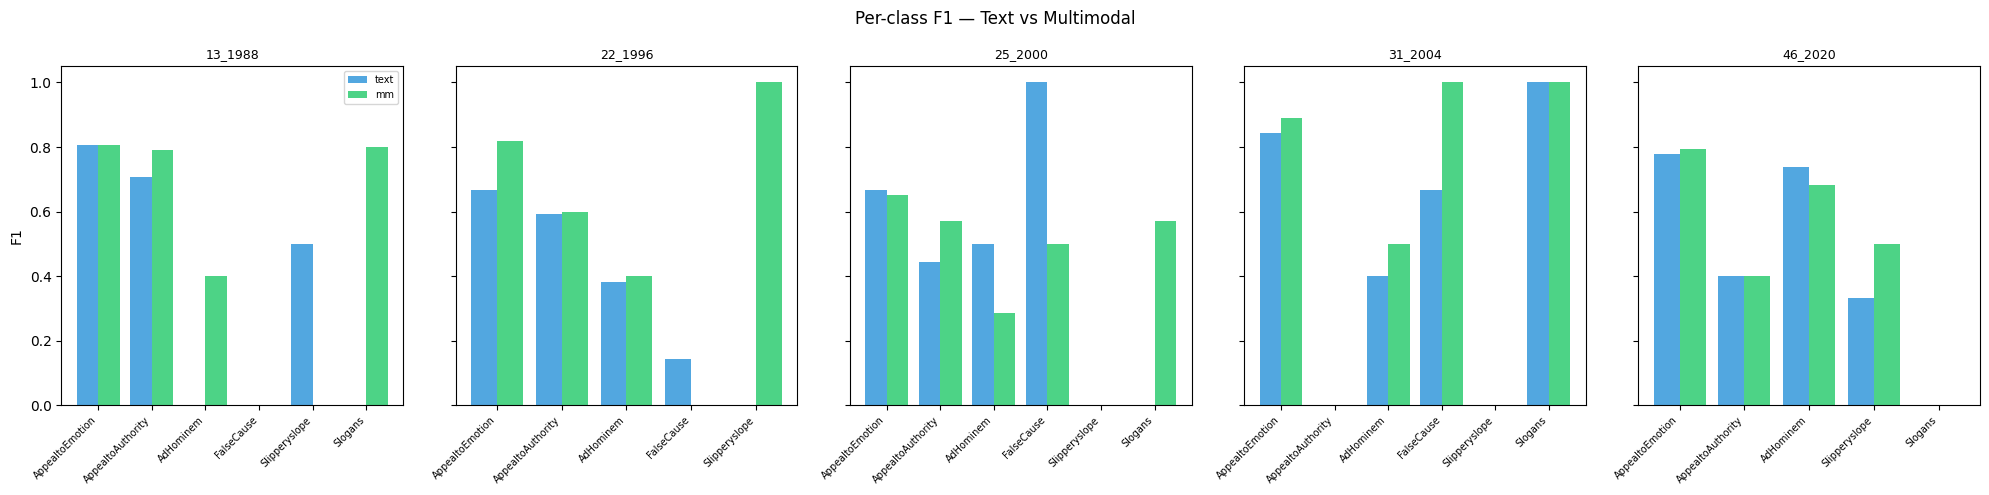

In [7]:
from analyses.comparison_analysis import plot_per_class_f1

plot_per_class_f1(
    text_results, mm_results,
    save_path=ROOT / "results/figures/per_class_text_vs_mm.png"
)

## 4. Deep dive — fold 25_2000

In [8]:
from analyses.comparison_analysis import print_fold_errors

print_fold_errors('25_2000', text_results, mm_results)

=== 25_2000 — class distribution ===
  AppealtoEmotion           n=21
  AppealtoAuthority         n=3
  AdHominem                 n=6
  FalseCause                n=3
  Slipperyslope             n=2
  Slogans                   n=5

=== Text errors (17) ===
  true=AppealtoEmotion           pred=AppealtoAuthority
  true=Slogans                   pred=AppealtoEmotion
  true=Slogans                   pred=AppealtoAuthority
  true=AdHominem                 pred=AppealtoAuthority
  true=Slogans                   pred=AppealtoEmotion
  true=Slogans                   pred=AppealtoAuthority
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=Slogans                   pred=AppealtoEmotion
  true=Slipperyslope             pred=AppealtoEmotion
  true=Slipperyslope             pred=AppealtoEmotion
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=AppealtoEmotion           pred=AdHominem
  true=App

## 5. Analyse longueur tokens — contexte vs limite RoBERTa 512

Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 12785.96it/s]


=== 25_2000 — token lengths (context+snippet) ===
  Min    : 33
  Max    : 189
  Mean   : 80.8
  > 512  : 0 / 40
  > 400  : 0 / 40

=== 25_2000 — token lengths (snippet only) ===
  Max    : 73
  Mean   : 26.1


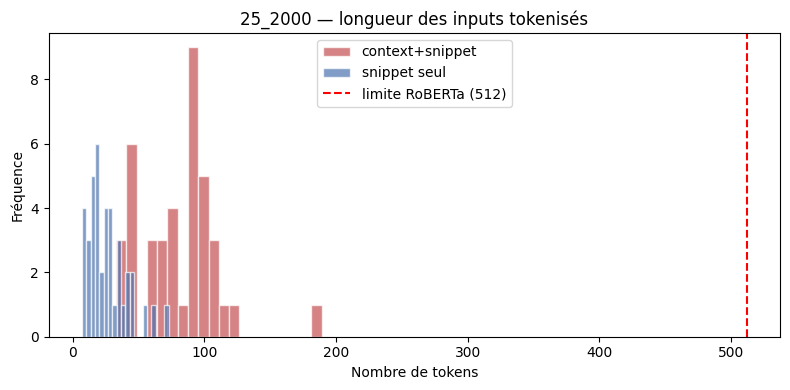

In [9]:
from analyses.comparison_analysis import plot_token_length_distribution

plot_token_length_distribution(
    '25_2000',
    base_data_path=ROOT / 'data',
    save_path=ROOT / 'results/figures/token_length_25_2000.png'
)